In [5]:
%pip install pandas numpy matplotlib seaborn -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Relatório de Análise de Vendas

Este notebook combina código, texto e visualizações para analisar os dados de vendas. A seguir, vamos carregar os dados, preparar as informações, explorar tendências e gerar gráficos que suportam as conclusões.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid', palette='muted')
%matplotlib inline

## Carregar os Dados de Vendas

Vamos ler o arquivo `vendas.csv` usando o pandas e verificar as primeiras linhas para entender a estrutura dos dados.

In [7]:
df = pd.read_csv('vendas.csv')
df.head()

,data,produto,quantidade,preço
0,2025-01-05,A,3,10.0
1,2025-01-20,B,1,20.0
2,2025-02-13,A,2,10.0
3,2025-02-25,C,5,15.0
4,2025-03-10,B,4,20.0


## Limpar e Preparar os Dados

Converteremos as datas para o formato adequado, criaremos colunas de receita e mês e verificaremos se existem valores nulos.

In [8]:
df['data'] = pd.to_datetime(df['data'], errors='coerce')
df['receita'] = df['quantidade'] * df['preço']
df['mes'] = df['data'].dt.to_period('M').astype(str)

print('Valores nulos por coluna:')
print(df.isna().sum())

df = df.dropna(subset=['data', 'produto', 'quantidade', 'preço'])
df.info()

Valores nulos por coluna:
data          0
produto       0
quantidade    0
preço         0
receita       0
mes           0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   data        5 non-null      datetime64[us]
 1   produto     5 non-null      str           
 2   quantidade  5 non-null      int64         
 3   preço       5 non-null      float64       
 4   receita     5 non-null      float64       
 5   mes         5 non-null      str           
dtypes: datetime64[us](1), float64(2), int64(1), str(2)
memory usage: 372.0 bytes


## Análise Exploratória de Dados

Vamos explorar as principais métricas da base, incluindo vendas por produto e por mês.

In [10]:
vendas_por_produto = df.groupby('produto')['receita'].sum().sort_values(ascending=False)
vendas_por_mes = df.groupby('mes')['receita'].sum().sort_index()

print('Receita por produto:')
print(vendas_por_produto)

print('\nReceita por mês:')
print(vendas_por_mes)

Receita por produto:
produto
B    100.0
C     75.0
A     50.0
Name: receita, dtype: float64

Receita por mês:
mes
2025-01    50.0
2025-02    95.0
2025-03    80.0
Name: receita, dtype: float64


## Criar Visualizações Gráficas

Geraremos gráficos de barras e linhas para visualizar a receita por produto e a evolução mensal das vendas.

C:\Users\vando\AppData\Local\Temp\ipykernel_19492\1922845077.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vendas_por_produto.index, y=vendas_por_produto.values, palette='viridis')


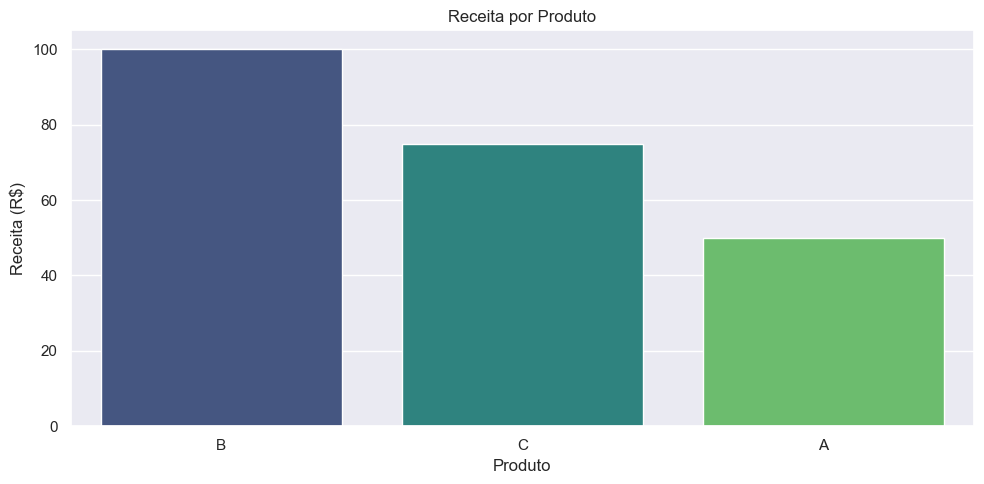

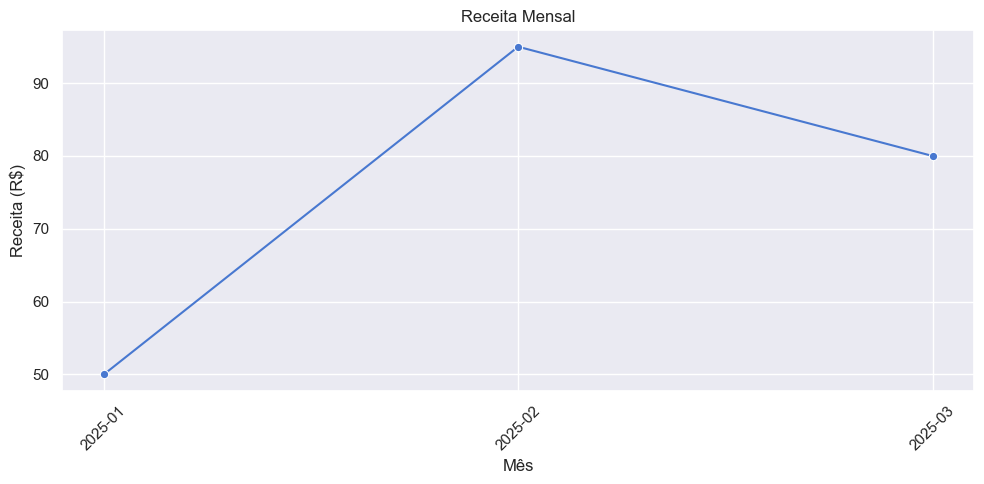

In [11]:
plt.figure(figsize=(10, 5))
sns.barplot(x=vendas_por_produto.index, y=vendas_por_produto.values, palette='viridis')
plt.title('Receita por Produto')
plt.xlabel('Produto')
plt.ylabel('Receita (R$)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.lineplot(x=vendas_por_mes.index, y=vendas_por_mes.values, marker='o')
plt.title('Receita Mensal')
plt.xlabel('Mês')
plt.ylabel('Receita (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Calcular Estatísticas Resumidas

Agora vamos calcular métricas importantes como total de vendas, média por produto e contribuição percentual de cada produto.

In [13]:
total_vendas = df['receita'].sum()
media_por_produto = df.groupby('produto')['receita'].mean().sort_values(ascending=False)
participacao_produto = (vendas_por_produto / total_vendas * 100).round(2)

print(f'Total de vendas: R$ {total_vendas:.2f}')
print('\nMédia de receita por produto:')
print(media_por_produto)
print('\nParticipação percentual por produto:')
print(participacao_produto)

Total de vendas: R$ 225.00

Média de receita por produto:
produto
C    75.0
B    50.0
A    25.0
Name: receita, dtype: float64

Participação percentual por produto:
produto
B    44.44
C    33.33
A    22.22
Name: receita, dtype: float64


## Gerar Relatório Final

Baseado nos dados, podemos observar quais são os produtos mais rentáveis e como a receita evoluiu ao longo dos meses. A seguir estão as principais conclusões.

In [14]:
mais_vendido = vendas_por_produto.idxmax()
receita_mais_vendida = vendas_por_produto.max()
mais_crescente = vendas_por_mes.idxmax()

print('Resumo do relatório:')
print(f'- Total de vendas: R$ {total_vendas:.2f}')
print(f'- Produto com maior receita: {mais_vendido} (R$ {receita_mais_vendida:.2f})')
print(f'- Mês com maior receita: {mais_crescente} (R$ {vendas_por_mes.max():.2f})')

if len(vendas_por_mes) > 1:
    crescimento = vendas_por_mes.pct_change().dropna() * 100
    print(f'- Crescimento médio mensal: {crescimento.mean():.2f}%')
else:
    print('- Não há meses suficientes para calcular crescimento percentual.')

Resumo do relatório:
- Total de vendas: R$ 225.00
- Produto com maior receita: B (R$ 100.00)
- Mês com maior receita: 2025-02 (R$ 95.00)
- Crescimento médio mensal: 37.11%
